# FIFA World Cup 2026 — Player Performance Analysis

Exploratory analysis of the FIFA World Cup 2026 player performance dataset
(54,600 player-match records across 48 teams). Loads the data, stores it in
SQLite, and builds a set of visualizations covering top performers,
demographics, and correlations between performance metrics.

**Note on the data:** the raw file is match-level — each player has one row
per match — and some columns (e.g. `total_goals_tournament`,
`player_of_match_awards`) are *cumulative running totals* rather than a
single final value. Anywhere we want one row per player (age distribution,
top scorers, etc.), we aggregate down to a player-level table first,
rather than working off the raw match rows directly.

In [2]:
import os
import sqlite3

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## 1. Load data

Tries the Kaggle dataset first, falls back to a local copy of the file if `kagglehub`/network access isn't available.

In [4]:
try:
    path = kagglehub.dataset_download(
        "rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset"
    )
    csv_path = os.path.join(path, "fifa_world_cup_2026_player_performance.csv")
    df = pd.read_csv(csv_path)
except Exception as e:
    print(f"kagglehub unavailable ({e}); falling back to local file.")
    df = pd.read_excel("FIFA_World_Cup_2026_Player_Data.xlsx")

print("Rows:", len(df))
print("Columns:", len(df.columns))
df.head()

Rows: 54600
Columns: 75


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


## 2. Store in SQLite

Makes the data queryable with SQL for the summary tables below.

In [6]:
conn = sqlite3.connect("fifa_wc2026.db")
df.to_sql("players", conn, if_exists="replace", index=False)

54600

Quick sanity check, and squad composition by position. Note `COUNT(DISTINCT player_id)`, not `COUNT(*)` — the table has ~44 rows per player, so a plain row count would just reflect match counts, not player counts.

In [8]:
pd.read_sql_query("SELECT * FROM players LIMIT 5;", conn)

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [9]:
position_summary = pd.read_sql_query("""
    SELECT
        position,
        COUNT(DISTINCT player_id) AS player_count
    FROM players
    GROUP BY position
    ORDER BY player_count DESC;
""", conn)

position_summary

,position,player_count
0,Defender,432
1,Midfielder,384
2,Forward,288
3,Goalkeeper,144


## 3. Build a player-level summary table

One row per player: bio fields are constant per player so any row's value
works, cumulative tournament totals use `MAX()`, and per-match stats like
rating are averaged with `AVG()`.

In [11]:
players_summary = pd.read_sql_query("""
    SELECT
        player_id,
        player_name,
        age,
        nationality,
        team,
        position,
        market_value_eur,
        MAX(total_goals_tournament) AS total_goals,
        MAX(total_assists_tournament) AS total_assists,
        MAX(player_of_match_awards) AS pom_awards,
        AVG(player_rating) AS avg_rating
    FROM players
    GROUP BY player_id;
""", conn)

print("Players:", len(players_summary))
players_summary.head()

Players: 1248


,player_id,player_name,age,nationality,team,position,market_value_eur,total_goals,total_assists,pom_awards,avg_rating
0,P00001,Kylian Griezmann,24,French,France,Goalkeeper,16574124,0,0,0,2.329412
1,P00002,Antoine Tchouameni,29,French,France,Goalkeeper,53959475,0,0,0,1.961765
2,P00003,Ousmane Hernandez,24,French,France,Goalkeeper,4935397,0,0,0,2.038235
3,P00004,Kylian Camavinga,27,French,France,Defender,3795900,1,2,0,3.473529
4,P00005,Antoine Kounde,24,French,France,Defender,21832889,1,1,0,4.270588


## 4. Player age vs. average rating

One point per player, using `players_summary` rather than the raw match rows.

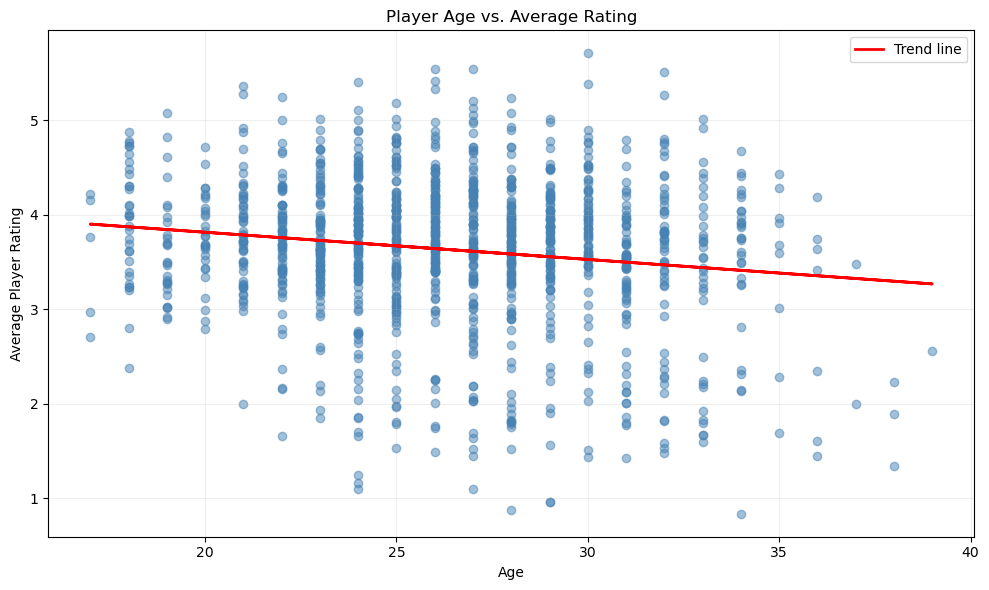

In [13]:
plot_df = players_summary[
    (players_summary["age"] > 0) & (players_summary["avg_rating"] > 0)
][["age", "avg_rating"]].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(plot_df["age"], plot_df["avg_rating"], alpha=0.5, color="steelblue")

z = np.polyfit(plot_df["age"], plot_df["avg_rating"], 1)
trend = np.poly1d(z)
plt.plot(plot_df["age"], trend(plot_df["age"]), color="red", linewidth=2, label="Trend line")

plt.title("Player Age vs. Average Rating")
plt.xlabel("Age")
plt.ylabel("Average Player Rating")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Findings:** The trend line drifts gently downward, from an average rating of roughly 3.9 at age 17 to about 3.3 at age 39, so older players skew slightly lower-rated on average. That said, the effect is small next to the spread at any given age — ratings span nearly the full 1–5.7 range for players in their early-to-mid 20s alone — so age alone doesn't explain much of the variation in performance.


## 5. Market value vs. average rating

Log-scaled market value, filtered to players valued above €10M to keep the trend readable.

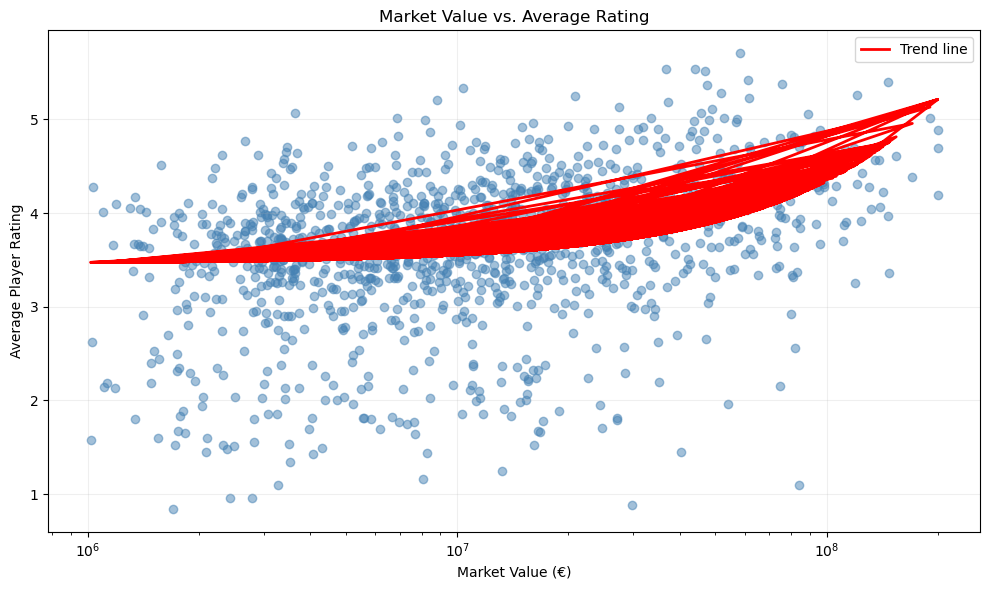

In [16]:
plot_df = players_summary[
    (players_summary["market_value_eur"] > 1_000_000) & (players_summary["avg_rating"] > 0)
][["market_value_eur", "avg_rating"]].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(plot_df["market_value_eur"], plot_df["avg_rating"], alpha=0.5, color="steelblue")

z = np.polyfit(plot_df["market_value_eur"], plot_df["avg_rating"], 1)
trend = np.poly1d(z)
plt.plot(plot_df["market_value_eur"], trend(plot_df["market_value_eur"]), color="red", linewidth=2, label="Trend line")

plt.title("Market Value vs. Average Rating")
plt.xlabel("Market Value (€)")
plt.ylabel("Average Player Rating")
plt.xscale("log")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Findings

Average rating trends upward with market value: below ~€20M, ratings are scattered widely (roughly 1.5–5.5), while above ~€100M they cluster more tightly in the 4–5 range with few low outliers. That's a stronger visual trend than the raw match-level correlation between market value and rating found in Section 8 likely because aggregating to one average rating per player smooths out the match-to-match noise that keeps the match-level correlation low. Note the trend line itself renders as a fan of crossing segments rather than a single smooth curve — an artifact of fitting on the raw (linear) values and then drawing it on a log-scaled x-axis — but the overall direction is still clear.

## 6. Top performers

Both now pull from `players_summary` (one row per player) instead of
`nlargest` on the raw match rows — since the totals are cumulative,
running `nlargest` on the raw data could pull in several rows from the
same player and bump other players out of the top 10.

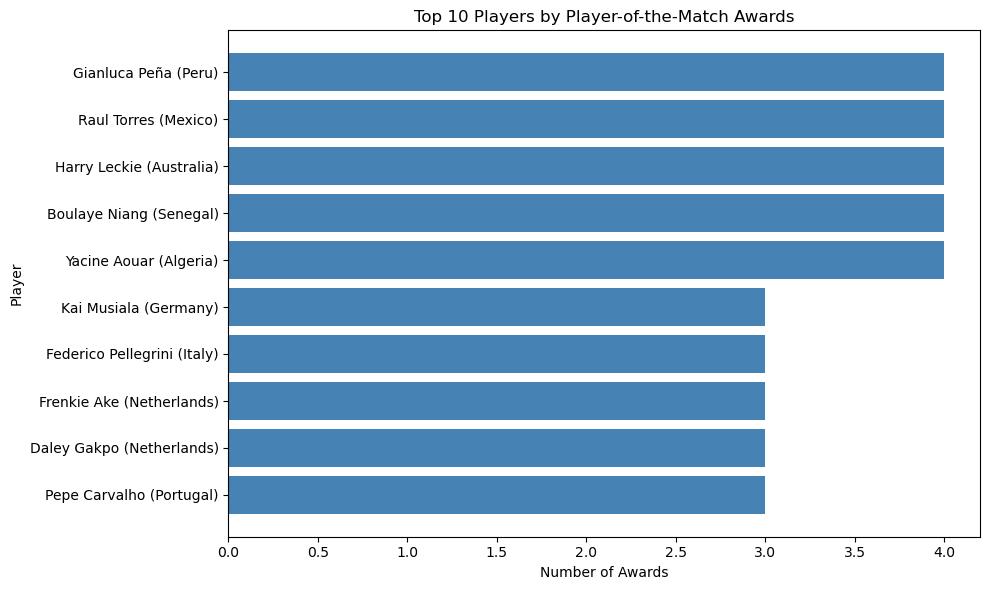

In [19]:
top_awards = players_summary.nlargest(10, "pom_awards")

plt.figure(figsize=(10, 6))
plt.barh(top_awards["player_name"], top_awards["pom_awards"], color="steelblue")

labels = [f"{name} ({team})" for name, team in zip(top_awards["player_name"], top_awards["team"])]
plt.yticks(range(len(top_awards)), labels)

plt.title("Top 10 Players by Player-of-the-Match Awards")
plt.xlabel("Number of Awards")
plt.ylabel("Player")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

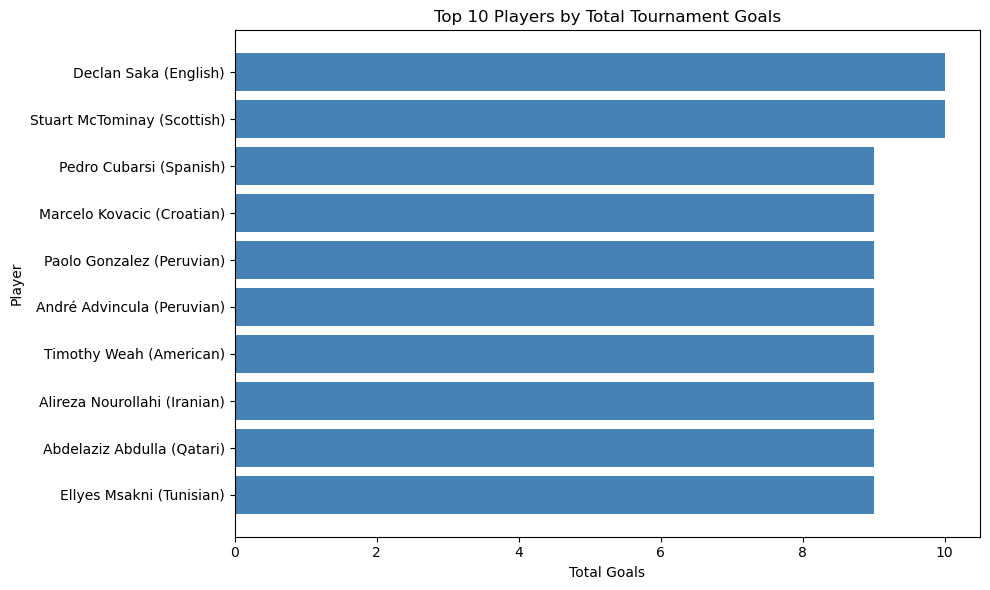

In [20]:
top_goals = players_summary.nlargest(10, "total_goals")

plt.figure(figsize=(10, 6))
plt.barh(top_goals["player_name"], top_goals["total_goals"], color="steelblue")

labels = [f"{name} ({nat})" for name, nat in zip(top_goals["player_name"], top_goals["nationality"])]
plt.yticks(range(len(top_goals)), labels)

plt.title("Top 10 Players by Total Tournament Goals")
plt.xlabel("Total Goals")
plt.ylabel("Player")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Findings:** The top scorers are tightly bunched — Declan Saka and Stuart McTominay lead with 10 tournament goals each, and eight more players (Cubarsi, Kovacic, Gonzalez, Advincula, Weah, Nourollahi, Abdulla, Msakni) are tied at 9, spanning eight different nationalities. Player-of-the-Match awards show the same flat pattern: five players (Peña, Torres, Leckie, Niang, Aouar) share the top spot with 4 awards apiece, and the rest of the top 10 sit at 3. In both cases there's no single standout — the tournament's best performances are spread across many players rather than concentrated in a few.


## 7. Age distribution

Also from `players_summary`, so each player is counted once regardless of how many matches they played.

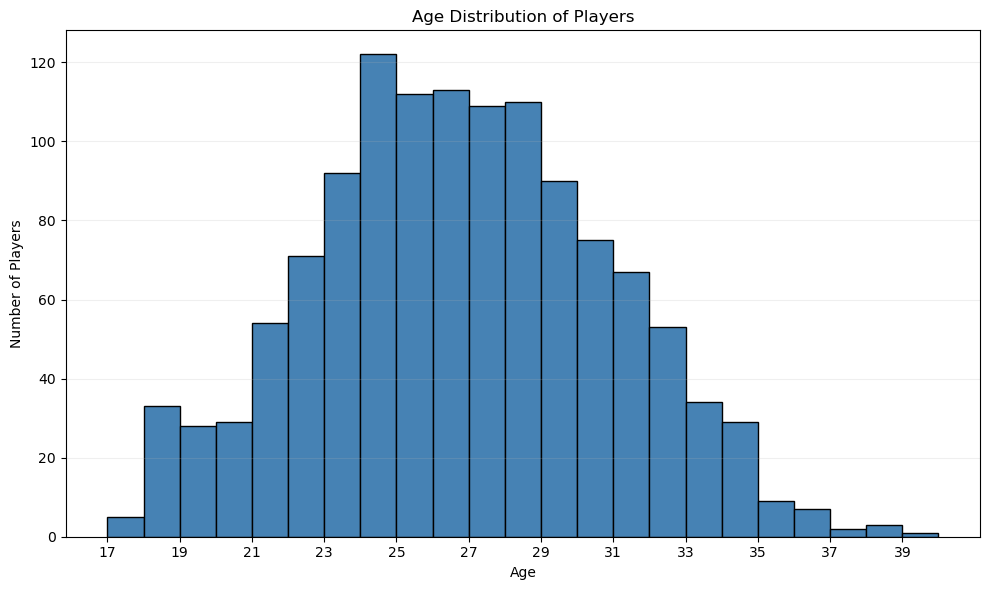

In [23]:
age_data = players_summary[players_summary["age"] > 0]["age"].dropna()

plt.figure(figsize=(10, 6))
plt.hist(
    age_data,
    bins=range(int(age_data.min()), int(age_data.max()) + 2),
    color="steelblue",
    edgecolor="black",
)

plt.title("Age Distribution of Players")
plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.xticks(range(int(age_data.min()), int(age_data.max()) + 1, 2))
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

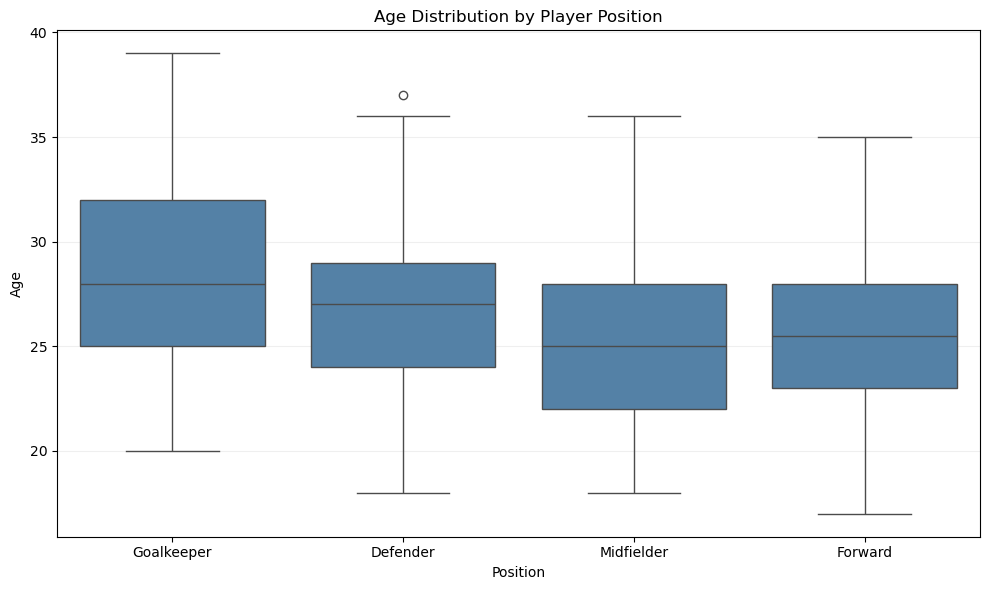

In [24]:
plot_df = players_summary[
    (players_summary["age"] > 0) & (players_summary["position"].notna())
]

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_df, x="position", y="age", color="steelblue")

plt.title("Age Distribution by Player Position")
plt.xlabel("Position")
plt.ylabel("Age")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

**Findings:** Ages are roughly bell-shaped and center on the mid-to-late 20s, peaking at 24 (122 players) and staying dense from 22–30 before tapering off sharply after 33; very few players are under 19 or over 37. Split by position, goalkeepers skew oldest (median 28, widest spread from 20–39), while midfielders have the youngest median (25) and the tightest interquartile range. Forwards have the widest age range overall (17–35) despite a median similar to defenders (~25.5–27).


## 8. Correlation between performance metrics

This section intentionally stays at **match level** rather than
player level — correlating per-match stats (shots, passes, etc.)
against per-match rating is a match-granularity question, so it
uses the raw `df`, not `players_summary`.

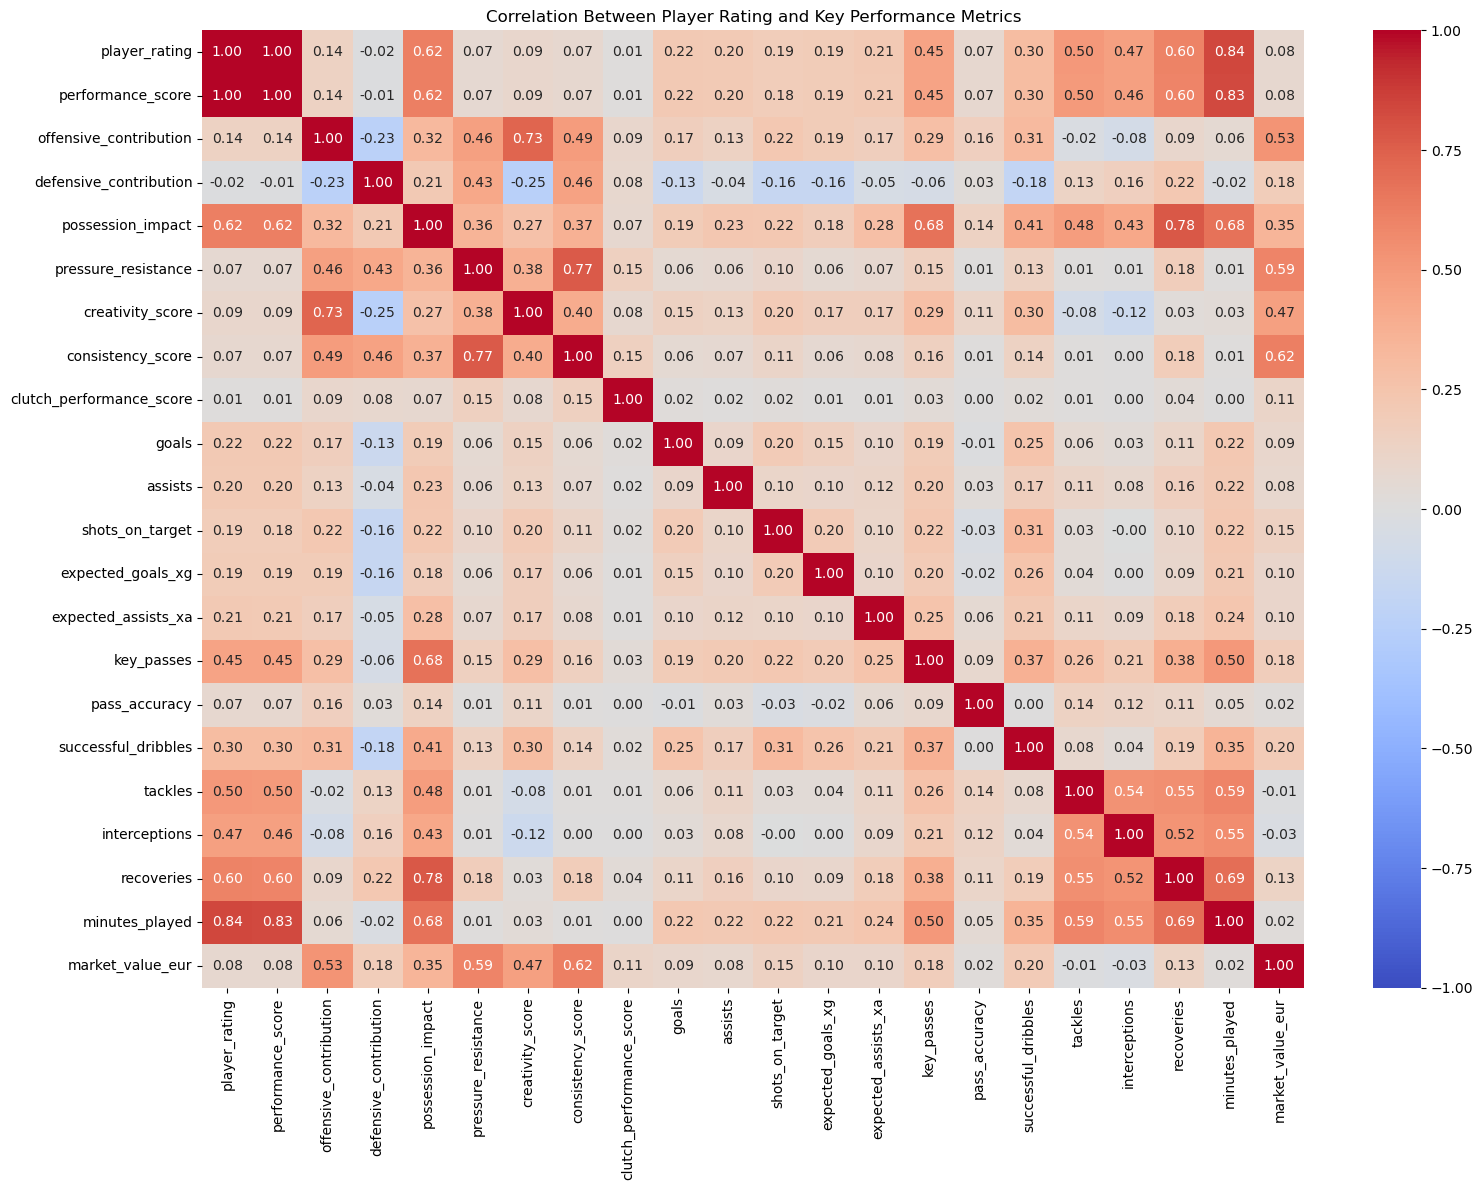

In [27]:
metrics = [
    "player_rating",
    "performance_score",
    "offensive_contribution",
    "defensive_contribution",
    "possession_impact",
    "pressure_resistance",
    "creativity_score",
    "consistency_score",
    "clutch_performance_score",
    "goals",
    "assists",
    "shots_on_target",
    "expected_goals_xg",
    "expected_assists_xa",
    "key_passes",
    "pass_accuracy",
    "successful_dribbles",
    "tackles",
    "interceptions",
    "recoveries",
    "minutes_played",
    "market_value_eur",
]

corr = df[metrics].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Correlation Between Player Rating and Key Performance Metrics")
plt.tight_layout()
plt.show()

In [28]:
correlations = (
    df[metrics]
    .corr()["player_rating"]
    .drop(["player_rating", "performance_score"])
    .sort_values(ascending=False)
)

correlations

minutes_played              0.837226
possession_impact           0.620474
recoveries                  0.602474
tackles                     0.501228
interceptions               0.465429
key_passes                  0.447363
successful_dribbles         0.301230
goals                       0.217196
expected_assists_xa         0.211172
assists                     0.204418
expected_goals_xg           0.193343
shots_on_target             0.185107
offensive_contribution      0.136353
creativity_score            0.086577
market_value_eur            0.075153
pass_accuracy               0.074662
consistency_score           0.070623
pressure_resistance         0.065578
clutch_performance_score    0.013010
defensive_contribution     -0.015169
Name: player_rating, dtype: float64

**Findings:** `minutes_played` is by far the strongest correlate of `player_rating` (0.84), followed by `possession_impact` (0.62), `recoveries` (0.60), `tackles` (0.50), `interceptions` (0.47), and `key_passes` (0.45) — the heatmap shows these same metrics driving most of the warm (positive) cells involving rating. The "glamour" attacking stats correlate only modestly: `goals` (0.22), `expected_assists_xa` (0.21), `assists` (0.20), and `expected_goals_xg` (0.19). Several metrics are essentially uncorrelated with rating: `clutch_performance_score` (0.01), `defensive_contribution` (-0.02), `pressure_resistance` (0.07), `consistency_score` (0.07), and `pass_accuracy` (0.07). `market_value_eur` also shows only a weak match-level correlation (0.08), consistent with the smoothing effect noted in Section 5. Separately, `player_rating` and `performance_score` are perfectly correlated (1.00), suggesting one is derived directly from the other.
